## Introduction

1. Download Stimulis 
2. Find the labels for each fMRI session
3. Try to plot using PyCortex

In [1]:
from laion_fmri import load_subject
import pandas as pd 
import numpy as np
import inspect
from scipy.spatial import cKDTree
import cortex
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from nibabel.freesurfer.io import read_geometry
from PIL import Image
import io
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
sub = load_subject("sub-01")
betas = sub.get_betas(session="ses-01",
                      roi=["V1v", "V1d", "V2v", "V2d", "V3v", "V3d"],
                      streaming=True)          # (n_trials, n_voxels)
trials = sub.get_trial_info(session="ses-01")    # pandas DataFrame

In [3]:
df = pd.DataFrame(trials)

In [4]:
print(betas.shape)
print(betas[0].shape)
print(type(betas))

(1044, 3621)
(3621,)
<class 'numpy.ndarray'>


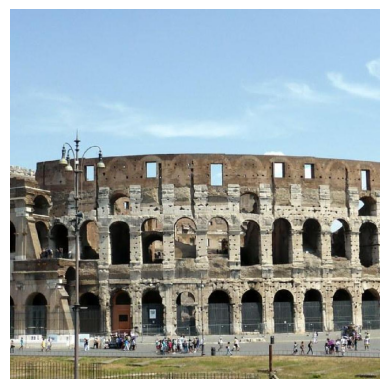

In [5]:
stimuli_dir = Path("/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/stimuli")
h5_path = stimuli_dir / "task-images_stimuli.h5"
with h5py.File(h5_path, "r") as f:
    data = f["images"][22187]
img = Image.open(io.BytesIO(data.tobytes()))
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
csv_path = stimuli_dir / "task-images_metadata.csv"
df = pd.read_csv(csv_path)

In [7]:
idx = df.index[df["image_name"] == "unique_LAION_new_cluster_475_i49_p01.jpg"][0]
print(idx)

22187


In [8]:
sub.get_freesurfer_dir()

PosixPath('/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/derivatives/freesurfer/sub-01')

In [9]:
coords = sub.get_voxel_coordinates(mask_source="anatomical")
coords.shape


(272080, 3)

In [10]:
surf_dir = Path(
    "/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/derivatives/freesurfer/sub-01/surf"
)
lh_vertices, lh_faces = read_geometry(f"{surf_dir}/lh.fiducial")
rh_vertices, rh_faces = read_geometry(f"{surf_dir}/rh.fiducial")

print("LH vertices:", lh_vertices.shape)
print("LH faces:", lh_faces.shape)

print("RH vertices:", rh_vertices.shape)
print("RH faces:", rh_faces.shape)

LH vertices: (148371, 3)
LH faces: (296738, 3)
RH vertices: (146299, 3)
RH faces: (292594, 3)


In [11]:
print("LAION voxel coordinates:")
print("min:", coords.min(axis=0))
print("max:", coords.max(axis=0))

LAION voxel coordinates:
min: [-66.16769559 -87.30168125 -61.95958755]
max: [63.61024858 92.25410453 87.37393716]


In [12]:
print("\nLH fiducial:")
print("min:", lh_vertices.min(axis=0))
print("max:", lh_vertices.max(axis=0))


LH fiducial:
min: [-61.30703735 -86.57471466 -31.7052803 ]
max: [ 7.31036377 82.86087799 77.96951294]


In [13]:
print("\nRH fiducial:")
print("min:", rh_vertices.min(axis=0))
print("max:", rh_vertices.max(axis=0))


RH fiducial:
min: [ -3.69707823 -83.03314209 -29.94981766]
max: [62.91252136 84.60449982 79.07966614]


In [14]:
lh_voxels = coords[:, 0] < 0
rh_voxels = coords[:, 0] > 0

print("LAION voxels with X < 0:", lh_voxels.sum())
print("LAION voxels with X > 0:", rh_voxels.sum())
print("LAION voxels with X = 0:", (coords[:, 0] == 0).sum())

LAION voxels with X < 0: 144792
LAION voxels with X > 0: 127288
LAION voxels with X = 0: 0


In [15]:
print("\nLAION LH-side coordinates:")
print("min:", coords[lh_voxels].min(axis=0))
print("max:", coords[lh_voxels].max(axis=0))

print("\nLAION RH-side coordinates:")
print("min:", coords[rh_voxels].min(axis=0))
print("max:", coords[rh_voxels].max(axis=0))


LAION LH-side coordinates:
min: [-66.16769559 -87.30168125 -61.95958755]
max: [-0.38983297 90.47632442 85.59615711]

LAION RH-side coordinates:
min: [  1.3879462  -83.74612106 -61.95958755]
max: [63.61024858 92.25410453 87.37393716]


In [16]:
print(cortex.database.default_filestore)

/home/rendo/projects/LAION_fMRI/pycortex-env/share/pycortex/db


In [17]:
print("pycortex version:", cortex.__version__)
print(inspect.signature(cortex.freesurfer.import_subj))

pycortex version: 1.3.2
(freesurfer_subject, pycortex_subject=None, freesurfer_subject_dir=None, whitematter_surf='smoothwm')


In [18]:
import cortex.freesurfer as fs

lh_patch = fs.parse_patch(
    str(surf_dir / "lh.cortex.patch.flat")
)

rh_patch = fs.parse_patch(
    str(surf_dir / "rh.cortex.patch.flat")
)

print("LH:", type(lh_patch), lh_patch.shape)
print("RH:", type(rh_patch), rh_patch.shape)
print("LH first rows:")
print(lh_patch[:5])

LH: <class 'numpy.ndarray'> (137276,)
RH: <class 'numpy.ndarray'> (136171,)
LH first rows:
[(1, 56.69557 , 135.5874 , 0.) (2, 56.476097, 134.37793, 0.)
 (3, 57.977997, 135.88434, 0.) (4, 57.136665, 134.11758, 0.)
 (5, 58.468445, 136.49817, 0.)]


In [20]:
lh_patch_idx = lh_patch["vertex"] - 1
rh_patch_idx = rh_patch["vertex"] - 1

print("LH patch index range:", lh_patch_idx.min(), lh_patch_idx.max())
print("LH surface vertices:", len(lh_vertices))

print("RH patch index range:", rh_patch_idx.min(), rh_patch_idx.max())
print("RH surface vertices:", len(rh_vertices))

ValueError: no field of name vertex

In [21]:
print(lh_patch.dtype)
print(lh_patch.dtype.names)

[('vert', '>i4'), ('x', '>f4'), ('y', '>f4'), ('z', '>f4')]
('vert', 'x', 'y', 'z')


In [22]:
lh_patch_idx = lh_patch["vert"] - 1
rh_patch_idx = rh_patch["vert"] - 1

print("LH patch index range:", lh_patch_idx.min(), lh_patch_idx.max())
print("LH surface vertices:", len(lh_vertices))

print("RH patch index range:", rh_patch_idx.min(), rh_patch_idx.max())
print("RH surface vertices:", len(rh_vertices))

print("LH unique indices:", len(np.unique(lh_patch_idx)))
print("RH unique indices:", len(np.unique(rh_patch_idx)))

LH patch index range: -148226 148370
LH surface vertices: 148371
RH patch index range: -146121 146298
RH surface vertices: 146299
LH unique indices: 137276
RH unique indices: 136171


In [23]:
lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1

print("LH patch index range:", lh_patch_idx.min(), lh_patch_idx.max())
print("LH surface vertices:", len(lh_vertices))

print("RH patch index range:", rh_patch_idx.min(), rh_patch_idx.max())
print("RH surface vertices:", len(rh_vertices))

print("LH unique:", len(np.unique(lh_patch_idx)))
print("RH unique:", len(np.unique(rh_patch_idx)))

LH patch index range: 0 148370
LH surface vertices: 148371
RH patch index range: 0 146298
RH surface vertices: 146299
LH unique: 137276
RH unique: 136171


In [24]:
# Single trial only
trial = np.asarray(betas[10])

# Split by hemisphere
lh_mask = coords[:, 0] < 0
rh_mask = coords[:, 0] > 0

# Build nearest-vertex lookup
lh_tree = cKDTree(lh_vertices)
rh_tree = cKDTree(rh_vertices)

_, lh_nearest = lh_tree.query(coords[lh_mask])
_, rh_nearest = rh_tree.query(coords[rh_mask])

# Accumulate beta values at surface vertices
lh_surface = np.full(len(lh_vertices), np.nan)
rh_surface = np.full(len(rh_vertices), np.nan)

# LH
lh_sum = np.zeros(len(lh_vertices))
lh_count = np.zeros(len(lh_vertices))

np.add.at(lh_sum, lh_nearest, trial[lh_mask])
np.add.at(lh_count, lh_nearest, 1)

valid = lh_count > 0
lh_surface[valid] = lh_sum[valid] / lh_count[valid]

# RH
rh_sum = np.zeros(len(rh_vertices))
rh_count = np.zeros(len(rh_vertices))

np.add.at(rh_sum, rh_nearest, trial[rh_mask])
np.add.at(rh_count, rh_nearest, 1)

valid = rh_count > 0
rh_surface[valid] = rh_sum[valid] / rh_count[valid]

print("LH surface values:", np.sum(~np.isnan(lh_surface)))
print("RH surface values:", np.sum(~np.isnan(rh_surface)))

IndexError: boolean index did not match indexed array along axis 0; size of axis is 3621 but size of corresponding boolean axis is 272080

In [25]:
# Patch vertex indices
lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1

# Flat coordinates
lh_flat_xy = np.column_stack([
    lh_patch["x"],
    lh_patch["y"]
])

rh_flat_xy = np.column_stack([
    rh_patch["x"],
    rh_patch["y"]
])

# Surface values corresponding to each patch vertex
lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]

print(lh_flat_xy.shape, lh_flat_values.shape)
print(rh_flat_xy.shape, rh_flat_values.shape)

(137276, 2) (137276,)
(136171, 2) (136171,)


In [26]:
def patch_faces(surface_faces, patch_indices):
    """
    Keep faces whose three vertices are present in the flat patch,
    and convert their global vertex indices to patch-local indices.
    """
    global_to_local = np.full(
        surface_faces.max() + 1,
        -1,
        dtype=np.int64
    )

    global_to_local[patch_indices] = np.arange(len(patch_indices))

    keep = np.all(global_to_local[surface_faces] >= 0, axis=1)

    faces = surface_faces[keep]

    return global_to_local[faces]


lh_flat_faces = patch_faces(lh_faces, lh_patch_idx)
rh_flat_faces = patch_faces(rh_faces, rh_patch_idx)

print("LH flat faces:", lh_flat_faces.shape)
print("RH flat faces:", rh_flat_faces.shape)

LH flat faces: (273600, 3)
RH flat faces: (271290, 3)


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


# =========================================================
# 1. Patch vertex indices
# =========================================================

lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1


# =========================================================
# 2. Convert FreeSurfer patch coordinates to pycortex
#    flatmap coordinates
#
#    This follows cortex.freesurfer.import_flat():
#
#        flat = pts[:, [1, 0, 2]]
#        flat[:, 1] = -flat[:, 1]
# =========================================================

lh_flat_xy = np.column_stack([
    lh_patch["y"],
    -lh_patch["x"]
])

rh_flat_xy = np.column_stack([
    rh_patch["y"],
    -rh_patch["x"]
])


# =========================================================
# 3. Get beta values for the flatmap vertices
# =========================================================

lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]


# =========================================================
# 4. Reconstruct the flatmap triangles
# =========================================================

def patch_faces(surface_faces, patch_indices):

    global_to_local = np.full(
        surface_faces.max() + 1,
        -1,
        dtype=np.int64
    )

    global_to_local[patch_indices] = np.arange(
        len(patch_indices)
    )

    keep = np.all(
        global_to_local[surface_faces] >= 0,
        axis=1
    )

    return global_to_local[surface_faces[keep]]


lh_flat_faces = patch_faces(
    lh_faces,
    lh_patch_idx
)

rh_flat_faces = patch_faces(
    rh_faces,
    rh_patch_idx
)


# =========================================================
# 5. Nudge the hemispheres apart
#
#    This follows pycortex's "nudge=True" convention:
#
#    LH → ends at x = 0
#    RH → starts at x = 0
# =========================================================

lh_plot = lh_flat_xy.copy()
rh_plot = rh_flat_xy.copy()

lh_plot[:, 0] -= lh_plot[:, 0].max()
rh_plot[:, 0] -= rh_plot[:, 0].min()


# Small gap between hemispheres
gap = 5

rh_plot[:, 0] += gap


# =========================================================
# 6. Create triangulations
# =========================================================

lh_tri = mtri.Triangulation(
    lh_plot[:, 0],
    lh_plot[:, 1],
    lh_flat_faces
)

rh_tri = mtri.Triangulation(
    rh_plot[:, 0],
    rh_plot[:, 1],
    rh_flat_faces
)


# =========================================================
# 7. One common color scale
# =========================================================

all_values = np.concatenate([
    lh_flat_values[np.isfinite(lh_flat_values)],
    rh_flat_values[np.isfinite(rh_flat_values)]
])

vmax = np.percentile(
    np.abs(all_values),
    98
)

vmin = -vmax


# =========================================================
# 8. Plot
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 7)
)


# Left hemisphere
im = ax.tripcolor(
    lh_tri,
    lh_flat_values,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)


# Right hemisphere
ax.tripcolor(
    rh_tri,
    rh_flat_values,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)


# =========================================================
# 9. Formatting
# =========================================================

ax.set_aspect("equal")
ax.axis("off")

ax.set_title(
    "LAION fMRI — trial 0"
)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.02,
    label="Beta activation"
)

plt.tight_layout()
plt.show()

IndexError: index -1 is out of bounds for axis 0 with size 0